# Modelos estadísticos

## Diplomado en técnicas estadísticas y minería de datos

### Examen — Análisis del comportamiento de las propinas (dataset `tips`)

**Autor:** Yago Raul Huerta Orozco (yagoraulhuertaorozco@gmail.com)

**Fecha:** 2 de octubre de 2026

---

<a id="indice"></a>
## Índice

- [Enunciado](#enunciado)
- [Configuración inicial](#setup)
- [1. Preparación de los datos](#sec1)
- [2. Análisis exploratorio de los datos](#sec2)
- [3. Inferencia estadística](#sec3)
- [4. Conclusiones y limitaciones del análisis realizado](#sec4)
- [5. Pregunta de investigación propia](#sec5)

<a id="enunciado"></a>
## Enunciado

Una cadena de restaurantes desea conocer el comportamiento de las propinas de sus clientes. En particular, desea determinar qué porcentaje de la cuenta representa la propina y si este porcentaje cambia dependiendo del día, horario o de otras características.


Realiza un análisis estadístico que permita responder estas preguntas.

Para tal fin, utiliza el conjunto de datos `tips`  disponible en el módulo `seaborn`.

No es suficiente presentar únicamente el código, tienes que interpretar los resultados o describir brevemente lo que hace el código al final de cada sección.

<a id="setup"></a>
## Configuración inicial

Se cargan los módulos necesarios para manipular datos (`pandas`, `numpy`), visualizar (`matplotlib`, `seaborn`) y realizar pruebas estadísticas (`scipy.stats`). También se define un tema gráfico y una paleta de colores consistentes para todas las figuras del cuaderno, y una función auxiliar `decision` que estandariza el reporte de cada prueba de hipótesis (H0, H1, alpha, valor-p y decisión).

In [1]:
# Cargar módulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.family": "sans-serif",
})

PALETTE_CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
COLOR_HIGHLIGHT = "#e34948"
ALPHA = 0.05  # nivel de significancia usado en todo el cuaderno


def decision(p_valor, alpha, h0_desc, h1_desc):
    # Reporta y devuelve la decision de una prueba a partir del valor-p
    if p_valor <= alpha:
        conclusion = f"Se rechaza H0 (valor-p = {p_valor:.4f} <= alpha = {alpha})"
        decision_txt = "Rechazar H0"
    else:
        conclusion = f"No se rechaza H0 (valor-p = {p_valor:.4f} > alpha = {alpha})"
        decision_txt = "No rechazar H0"
    print(f"  H0            : {h0_desc}")
    print(f"  H1            : {h1_desc}")
    print(f"  alpha         : {alpha}")
    print(f"  valor-p       : {p_valor:.6f}")
    print(f"  Decision      : {decision_txt}")
    print(f"  Conclusion    : {conclusion}")
    return conclusion


print("Modulos, tema grafico y utilidades cargados.")

Modulos, tema grafico y utilidades cargados.


In [2]:
# Cargar el conjunto de datos tips
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


El conjunto `tips` registra 244 visitas a un restaurante, con el monto de la cuenta (`total_bill`), la propina (`tip`), el sexo de quien paga, si es fumador, el día, el horario (almuerzo/cena) y el tamaño del grupo (`size`). Es la base sobre la que se construye todo el análisis que sigue.

<a id="sec1"></a>
## 1. Preparación de los datos **[2 puntos]**

Antes de analizar el comportamiento de las propinas se revisa la calidad de los datos (tipos, nulos, duplicados), se construye la variable de interés —el **porcentaje de propina**— y se identifican posibles valores atípicos.

In [3]:
# 1.1 Estructura y tipos de datos
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df.info()

Dimensiones: 244 filas x 7 columnas

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


El conjunto tiene 244 registros y 7 columnas sin ningún valor nulo. `total_bill`, `tip` son numéricas continuas y `size` es entera; `sex`, `smoker`, `day` y `time` ya vienen codificadas por `seaborn` como `category`, lo que facilita los grupos que se usarán en las secciones 2 y 3.

In [4]:
# 1.2 Valores nulos y filas duplicadas
print("Valores nulos por columna:")
print(df.isna().sum())
print(f"\nFilas completamente duplicadas: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensiones despues de eliminar duplicados: {df.shape}")

Valores nulos por columna:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Filas completamente duplicadas: 1
Dimensiones despues de eliminar duplicados: (243, 7)


No hay valores nulos, pero sí **una fila completamente duplicada** (misma cuenta, propina, sexo, fumador, día, horario y tamaño de grupo), que se elimina para evitar contar dos veces la misma observación. El conjunto de trabajo queda con **243 filas**.

In [5]:
# 1.3 Variable de interes: porcentaje de propina
df["pct_tip"] = df["tip"] / df["total_bill"] * 100

# Orden logico de los dias (de entre semana a fin de semana) para que los
# graficos y tablas de las secciones siguientes respeten ese orden
df["day"] = df["day"].cat.set_categories(["Thur", "Fri", "Sat", "Sun"], ordered=True)

df[["total_bill", "tip", "pct_tip"]].describe()

,total_bill,tip,pct_tip
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,16.083121
std,8.910071,1.385002,6.119662
min,3.070000,1.000000,3.563814
25%,13.380000,2.000000,12.883281
50%,17.810000,2.920000,15.521855
75%,24.175000,3.575000,19.174638
max,50.810000,10.000000,71.034483


Se crea `pct_tip = tip / total_bill * 100`, la variable que responde directamente la pregunta del enunciado. En promedio los clientes dejan **16.08 %** de propina (DE = 6.12 puntos porcentuales), con una mediana de 15.52 %; es decir, la propina "típica" ronda el 15-16 % de la cuenta, aunque la dispersión es considerable (de 3.56 % a 71.03 %).

In [6]:
# 1.4 Deteccion de posibles valores atipicos en pct_tip
z_scores = np.abs(stats.zscore(df["pct_tip"]))
outliers = df.loc[z_scores > 3, ["total_bill", "tip", "pct_tip", "day", "time", "size"]]
print(f"Filas con |z| > 3 en pct_tip: {len(outliers)}")
outliers

Filas con |z| > 3 en pct_tip: 2


,total_bill,tip,pct_tip,day,time,size
172,7.25,5.15,71.034483,Sun,Dinner,2
178,9.60,4.00,41.666667,Sun,Dinner,2


Hay **2 observaciones** con `pct_tip` a más de 3 desviaciones estándar de la media, entre ellas el caso extremo de una cuenta de $7.25 con $5.15 de propina (71 %). No son errores de captura —son cuentas pequeñas en las que una propina fija relativamente generosa se traduce en un porcentaje muy alto— por lo que **se conservan**: eliminarlas sesgaría el análisis hacia abajo y no hay evidencia de que sean datos corruptos. Se tendrán en cuenta como posible fuente de asimetría al interpretar las pruebas de la sección 3.

<a id="sec2"></a>
## 2. Análisis exploratorio de los datos **[2 puntos]**

Se explora visual y numéricamente cómo se distribuye `pct_tip` en general y por día, horario, sexo y condición de fumador, y cómo se relaciona con el monto de la cuenta y el tamaño del grupo.

In [7]:
# 2.1 Estadistica descriptiva de pct_tip por grupo
for col in ["day", "time", "sex", "smoker"]:
    print(f"--- pct_tip por {col} ---")
    print(df.groupby(col)["pct_tip"].agg(["mean", "std", "count"]).round(2))
    print()

--- pct_tip por day ---
       mean   std  count
day                     
Thur  16.14  3.90     61
Fri   16.99  4.77     19
Sat   15.32  5.13     87
Sun   16.69  8.47     76

--- pct_tip por time ---
         mean   std  count
time                      
Lunch   16.43  4.05     67
Dinner  15.95  6.75    176

--- pct_tip por sex ---
         mean   std  count
sex                       
Male    15.77  6.48    157
Female  16.66  5.39     86

--- pct_tip por smoker ---
         mean   std  count
smoker                    
Yes     16.33  8.56     92
No      15.93  3.99    151



Las medias por grupo son parecidas entre sí y las diferencias son pequeñas frente a la dispersión dentro de cada grupo: por día van de 15.32 % (sábado) a 16.99 % (viernes); por horario, almuerzo (16.43 %) es apenas superior a cena (15.95 %); por sexo, mujeres (16.66 %) un poco por encima de hombres (15.77 %); por condición de fumador, fumadores (16.33 %) ligeramente por encima de no fumadores (15.93 %). A simple vista ninguna diferencia parece grande, pero conviene confirmarlo con pruebas formales en la sección 3.

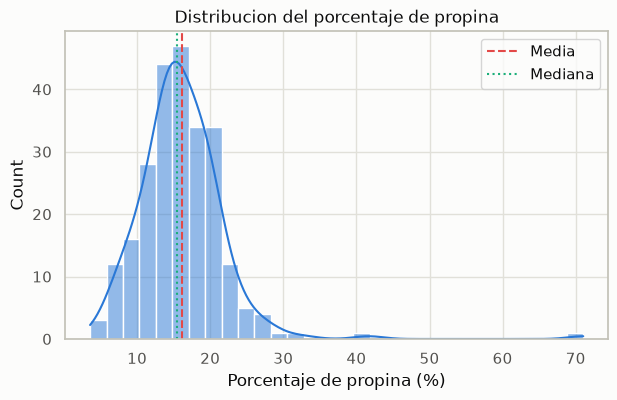

In [8]:
# 2.2 Distribucion general de pct_tip
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["pct_tip"], bins=30, kde=True, color=PALETTE_CATEGORICAL[0], ax=ax)
ax.axvline(df["pct_tip"].mean(), color=COLOR_HIGHLIGHT, linestyle="--", label="Media")
ax.axvline(df["pct_tip"].median(), color=PALETTE_CATEGORICAL[2], linestyle=":", label="Mediana")
ax.set_xlabel("Porcentaje de propina (%)")
ax.set_title("Distribucion del porcentaje de propina")
ax.legend()
plt.show()

La distribución de `pct_tip` es **unimodal y sesgada a la derecha**: la mayoría de las propinas se concentra entre 10 % y 20 %, pero la cola derecha (impulsada por los outliers de la sección 1.4) estira la media por encima de la mediana. Este sesgo es relevante para la sección 3: varias pruebas paramétricas asumen normalidad, que aquí no se cumple de forma estricta.

/tmp/ipykernel_21147/1600300515.py:4: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(data=df, x="day", y="pct_tip", hue="day", legend=False,
/tmp/ipykernel_21147/1600300515.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(data=df, x="time", y="pct_tip", hue="time", legend=False,


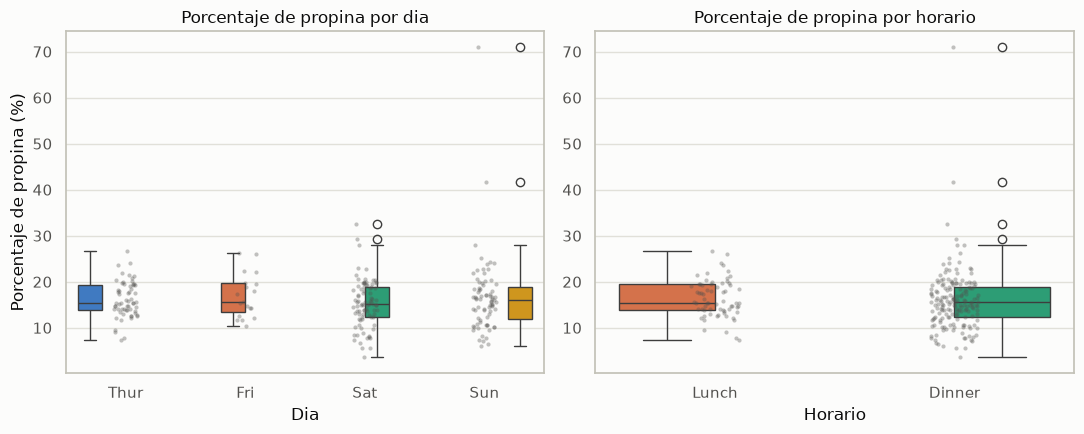

In [9]:
# 2.3 pct_tip por dia y por horario
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=df, x="day", y="pct_tip", hue="day", legend=False,
            palette=PALETTE_CATEGORICAL, ax=axes[0])
sns.stripplot(data=df, x="day", y="pct_tip", color="#52514e", alpha=0.35, size=3, ax=axes[0])
axes[0].set_title("Porcentaje de propina por dia")
axes[0].set_xlabel("Dia")
axes[0].set_ylabel("Porcentaje de propina (%)")

sns.boxplot(data=df, x="time", y="pct_tip", hue="time", legend=False,
            palette=PALETTE_CATEGORICAL[1:], ax=axes[1])
sns.stripplot(data=df, x="time", y="pct_tip", color="#52514e", alpha=0.35, size=3, ax=axes[1])
axes[1].set_title("Porcentaje de propina por horario")
axes[1].set_xlabel("Horario")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Las cajas de día y horario se solapan casi por completo; el único rasgo distintivo es que **domingo** muestra la mayor variabilidad (y aloja el outlier de 71 %), mientras que los demás grupos se comportan de forma similar. Visualmente no hay indicios claros de que el día o el horario, por sí solos, modifiquen el porcentaje de propina.

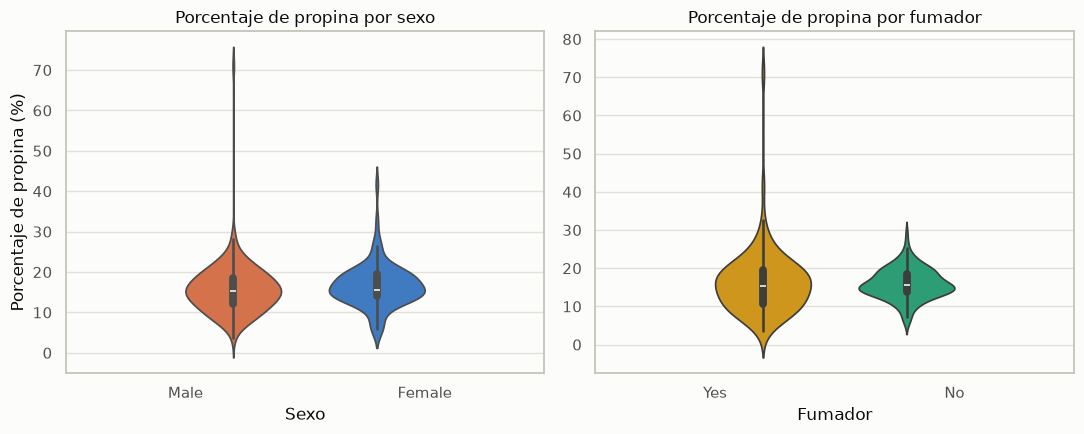

In [10]:
# 2.4 pct_tip por sexo y por condicion de fumador
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.violinplot(data=df, x="sex", y="pct_tip", hue="sex", legend=False,
               palette=PALETTE_CATEGORICAL[:2], ax=axes[0])
axes[0].set_title("Porcentaje de propina por sexo")
axes[0].set_xlabel("Sexo")
axes[0].set_ylabel("Porcentaje de propina (%)")

sns.violinplot(data=df, x="smoker", y="pct_tip", hue="smoker", legend=False,
               palette=PALETTE_CATEGORICAL[2:4], ax=axes[1])
axes[1].set_title("Porcentaje de propina por fumador")
axes[1].set_xlabel("Fumador")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Las distribuciones de hombres/mujeres y fumadores/no fumadores son muy similares en forma y centro; la de **fumadores** es algo más ancha (mayor dispersión), coherente con la desviación estándar más alta observada en la tabla 2.1 (8.56 vs 3.99 puntos porcentuales), pero el centro de ambas distribuciones no se diferencia de forma notoria.

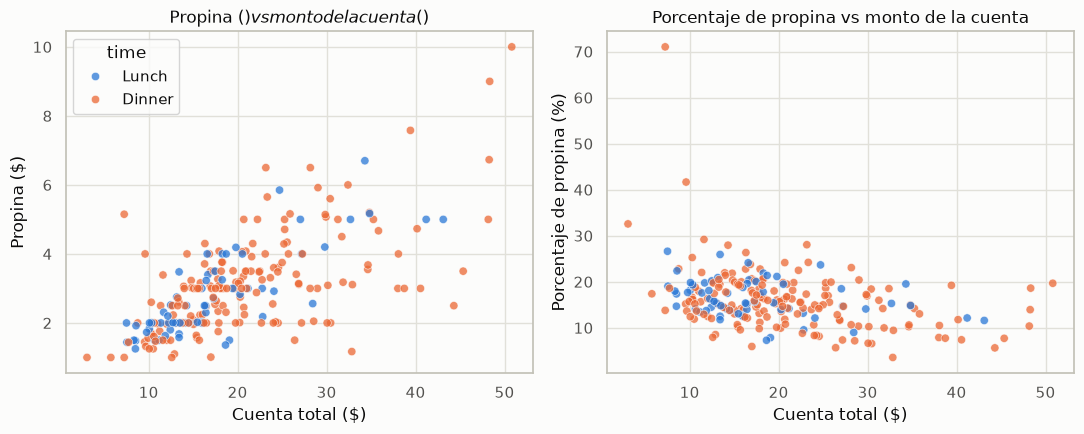

In [11]:
# 2.5 Relacion entre el monto de la cuenta y la propina
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.scatterplot(data=df, x="total_bill", y="tip", hue="time",
                 palette=PALETTE_CATEGORICAL[:2], alpha=0.75, ax=axes[0])
axes[0].set_title("Propina ($) vs monto de la cuenta ($)")
axes[0].set_xlabel("Cuenta total ($)")
axes[0].set_ylabel("Propina ($)")

sns.scatterplot(data=df, x="total_bill", y="pct_tip", hue="time",
                 palette=PALETTE_CATEGORICAL[:2], alpha=0.75, ax=axes[1], legend=False)
axes[1].set_title("Porcentaje de propina vs monto de la cuenta")
axes[1].set_xlabel("Cuenta total ($)")
axes[1].set_ylabel("Porcentaje de propina (%)")

plt.tight_layout()
plt.show()

El panel izquierdo muestra una relación **positiva y clara** entre el monto de la cuenta y la propina en dólares: cuentas más grandes generan propinas más grandes. Sin embargo, el panel derecho revela que, en términos de **porcentaje**, la relación se invierte ligeramente: a medida que la cuenta crece, el porcentaje de propina tiende a **disminuir** y a dispersarse menos (las cuentas pequeñas son las que producen los porcentajes más altos y más variables). Esto se confirma formalmente en la sección 3.

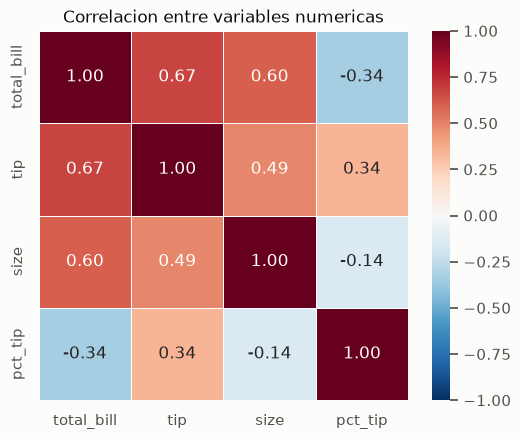

In [12]:
# 2.6 Mapa de correlacion entre variables numericas
fig, ax = plt.subplots(figsize=(5.5, 4.5))
corr = df[["total_bill", "tip", "size", "pct_tip"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()

`total_bill` y `tip` están fuertemente correlacionadas (r ≈ 0.68), como ya sugería el dispersograma. En cambio, `pct_tip` se correlaciona **negativamente** con `total_bill` (r ≈ -0.34) y de forma débil con `size` (r ≈ -0.14): mientras más grande la cuenta o el grupo, menor tiende a ser el porcentaje de propina relativo. Estas son las relaciones que se prueban formalmente a continuación.

In [13]:
# 2.7 Composicion de la muestra: dia vs horario
tabla_dia_horario = pd.crosstab(df["day"], df["time"])
tabla_dia_horario

time,Lunch,Dinner
day,,
Thur,60,1
Fri,7,12
Sat,0,87
Sun,0,76


Esta tabla revela algo importante para la sección 3: **día y horario no varían de forma independiente en esta muestra**. Casi todas las visitas de jueves son almuerzo (60 de 61), casi todas las de sábado y domingo son cena (87 y 76, respectivamente), y viernes es el único día con una mezcla real de ambos horarios. Esto significa que "efecto del día" y "efecto del horario" están parcialmente confundidos entre sí: no se pueden interpretar como factores completamente independientes.

<a id="sec3"></a>
## 3. Inferencia estadística **[3 puntos]**

Para cada comparación se trabaja con alpha = 0.05 y se sigue el mismo protocolo: primero se evalúa el supuesto de normalidad por grupo con la prueba de **Shapiro-Wilk** y, cuando aplica, la igualdad de varianzas con la prueba de **Levene**; después se reporta la prueba paramétrica correspondiente junto con su alternativa no paramétrica, para verificar que la conclusión no dependa de los supuestos distribucionales.

### 3.1 ¿Cambia el porcentaje de propina entre fin de semana y entre semana?

$$
H_0: \mu_{\text{finde}} = \mu_{\text{entresemana}} \qquad \text{vs.} \qquad H_1: \mu_{\text{finde}} \neq \mu_{\text{entresemana}}
$$

In [14]:
finde = df["day"].isin(["Sat", "Sun"])
pct_finde = df.loc[finde, "pct_tip"]
pct_entresemana = df.loc[~finde, "pct_tip"]

print(f"n finde = {len(pct_finde)}, n entre semana = {len(pct_entresemana)}\n")
print("Normalidad (Shapiro-Wilk):")
print("  finde         :", stats.shapiro(pct_finde))
print("  entre semana  :", stats.shapiro(pct_entresemana))
print("\nIgualdad de varianzas (Levene):", stats.levene(pct_finde, pct_entresemana))

t_stat, p_t = stats.ttest_ind(pct_finde, pct_entresemana)
u_stat, p_u = stats.mannwhitneyu(pct_finde, pct_entresemana)
print(f"\nt de Student   : t = {t_stat:.4f}")
decision(p_t, ALPHA, "mu_finde = mu_entresemana", "mu_finde != mu_entresemana")
print(f"\nMann-Whitney U : U = {u_stat:.1f}")
decision(p_u, ALPHA, "misma distribucion finde/entresemana", "distribuciones distintas")

n finde = 163, n entre semana = 80

Normalidad (Shapiro-Wilk):
  finde         : ShapiroResult(statistic=np.float64(0.7694215083389979), pvalue=np.float64(9.866552795646722e-15))
  entre semana  : ShapiroResult(statistic=np.float64(0.9786595592361221), pvalue=np.float64(0.20146771191581536))

Igualdad de varianzas (Levene): LeveneResult(statistic=np.float64(2.8254934694582605), pvalue=np.float64(0.0940738832515983))

t de Student   : t = -0.4612
  H0            : mu_finde = mu_entresemana
  H1            : mu_finde != mu_entresemana
  alpha         : 0.05
  valor-p       : 0.645065
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.6451 > alpha = 0.05)

Mann-Whitney U : U = 5985.5
  H0            : misma distribucion finde/entresemana
  H1            : distribuciones distintas
  alpha         : 0.05
  valor-p       : 0.299714
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.2997 > alpha = 0.05)


'No se rechaza H0 (valor-p = 0.2997 > alpha = 0.05)'

**Conclusión 3.1.** La distribución del fin de semana no es normal (Shapiro p ≈ 9.9e-15, por el outlier del domingo), pero las varianzas no difieren de forma significativa (Levene p ≈ 0.094). Tanto la prueba t (p ≈ 0.645) como su alternativa no paramétrica Mann-Whitney (p ≈ 0.300) **no rechazan H0**: no hay evidencia de que el porcentaje de propina sea distinto entre fin de semana y entre semana. Como las dos pruebas coinciden, la conclusión es robusta a la falta de normalidad.

### 3.2 ¿Cambia el porcentaje de propina entre almuerzo y cena?

$$
H_0: \mu_{\text{almuerzo}} = \mu_{\text{cena}} \qquad \text{vs.} \qquad H_1: \mu_{\text{almuerzo}} \neq \mu_{\text{cena}}
$$

In [15]:
pct_lunch = df.loc[df["time"] == "Lunch", "pct_tip"]
pct_dinner = df.loc[df["time"] == "Dinner", "pct_tip"]

print(f"n almuerzo = {len(pct_lunch)}, n cena = {len(pct_dinner)}\n")
print("Normalidad (Shapiro-Wilk):")
print("  almuerzo :", stats.shapiro(pct_lunch))
print("  cena     :", stats.shapiro(pct_dinner))
print("\nIgualdad de varianzas (Levene):", stats.levene(pct_lunch, pct_dinner))

t_stat, p_t = stats.ttest_ind(pct_lunch, pct_dinner, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(pct_lunch, pct_dinner)
print(f"\nt de Welch     : t = {t_stat:.4f}")
decision(p_t, ALPHA, "mu_almuerzo = mu_cena", "mu_almuerzo != mu_cena")
print(f"\nMann-Whitney U : U = {u_stat:.1f}")
decision(p_u, ALPHA, "misma distribucion almuerzo/cena", "distribuciones distintas")

n almuerzo = 67, n cena = 176

Normalidad (Shapiro-Wilk):
  almuerzo : ShapiroResult(statistic=np.float64(0.9834967160438928), pvalue=np.float64(0.5171323086274736))
  cena     : ShapiroResult(statistic=np.float64(0.7752610783191415), pvalue=np.float64(3.759562596641773e-15))

Igualdad de varianzas (Levene): LeveneResult(statistic=np.float64(2.1892807215101464), pvalue=np.float64(0.14028016658247555))

t de Welch     : t = 0.6711
  H0            : mu_almuerzo = mu_cena
  H1            : mu_almuerzo != mu_cena
  alpha         : 0.05
  valor-p       : 0.502936
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.5029 > alpha = 0.05)

Mann-Whitney U : U = 6490.5
  H0            : misma distribucion almuerzo/cena
  H1            : distribuciones distintas
  alpha         : 0.05
  valor-p       : 0.225100
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.2251 > alpha = 0.05)


'No se rechaza H0 (valor-p = 0.2251 > alpha = 0.05)'

**Conclusión 3.2.** La cena tampoco es normal (Shapiro p ≈ 3.8e-15), pero las varianzas de ambos grupos son estadísticamente comparables (Levene p ≈ 0.140). La prueba t de Welch (p ≈ 0.503) y Mann-Whitney (p ≈ 0.225) coinciden en **no rechazar H0**: el porcentaje de propina no difiere significativamente entre almuerzo y cena. Dado el hallazgo de la sección 2.7 (día y horario confundidos), este resultado también implica que el "efecto día" tampoco puede explicarse por el horario.

### 3.3 ¿Cambia el porcentaje de propina entre fumadores y no fumadores?

$$
H_0: \mu_{\text{fumador}} = \mu_{\text{no fumador}} \qquad \text{vs.} \qquad H_1: \mu_{\text{fumador}} \neq \mu_{\text{no fumador}}
$$

In [16]:
pct_smoker = df.loc[df["smoker"] == "Yes", "pct_tip"]
pct_nonsmoker = df.loc[df["smoker"] == "No", "pct_tip"]

print(f"n fumador = {len(pct_smoker)}, n no fumador = {len(pct_nonsmoker)}\n")
print("Normalidad (Shapiro-Wilk):")
print("  fumador    :", stats.shapiro(pct_smoker))
print("  no fumador :", stats.shapiro(pct_nonsmoker))
print("\nIgualdad de varianzas (Levene):", stats.levene(pct_smoker, pct_nonsmoker))

t_stat, p_t = stats.ttest_ind(pct_smoker, pct_nonsmoker, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(pct_smoker, pct_nonsmoker)
print(f"\nt de Welch     : t = {t_stat:.4f}")
decision(p_t, ALPHA, "mu_fumador = mu_no_fumador", "mu_fumador != mu_no_fumador")
print(f"\nMann-Whitney U : U = {u_stat:.1f}")
decision(p_u, ALPHA, "misma distribucion fumador/no fumador", "distribuciones distintas")

n fumador = 92, n no fumador = 151

Normalidad (Shapiro-Wilk):
  fumador    : ShapiroResult(statistic=np.float64(0.763678631515729), pvalue=np.float64(7.399299490320693e-11))
  no fumador : ShapiroResult(statistic=np.float64(0.9893149144684967), pvalue=np.float64(0.30617461659262846))

Igualdad de varianzas (Levene): LeveneResult(statistic=np.float64(15.431395737355047), pvalue=np.float64(0.00011177339723761181))

t de Welch     : t = 0.4180
  H0            : mu_fumador = mu_no_fumador
  H1            : mu_fumador != mu_no_fumador
  alpha         : 0.05
  valor-p       : 0.676702
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.6767 > alpha = 0.05)

Mann-Whitney U : U = 6635.5
  H0            : misma distribucion fumador/no fumador
  H1            : distribuciones distintas
  alpha         : 0.05
  valor-p       : 0.559707
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.5597 > alpha = 0.05)


'No se rechaza H0 (valor-p = 0.5597 > alpha = 0.05)'

**Conclusión 3.3.** Aquí sí hay una diferencia marcada en la **variabilidad**: Levene rechaza la igualdad de varianzas (p ≈ 0.00011), por lo que se usa directamente la t de Welch (no asume varianzas iguales). Tanto la t de Welch (p ≈ 0.677) como Mann-Whitney (p ≈ 0.560) **no rechazan H0**: ser fumador no se asocia con un porcentaje de propina distinto en promedio, aunque sí con una propina mucho más dispersa (DE ≈ 8.56 % vs 3.99 %).

### 3.4 ¿Cambia el porcentaje de propina entre los cuatro días de la semana?

$$
H_0: \mu_{\text{jue}} = \mu_{\text{vie}} = \mu_{\text{sab}} = \mu_{\text{dom}} \qquad \text{vs.} \qquad H_1: \text{al menos una media es distinta}
$$

In [17]:
grupos_dia = [df.loc[df["day"] == d, "pct_tip"] for d in df["day"].cat.categories]

print("Normalidad (Shapiro-Wilk) por dia:")
for d, g in zip(df["day"].cat.categories, grupos_dia):
    print(f"  {d:5s} (n={len(g):3d}):", stats.shapiro(g))
print("\nIgualdad de varianzas (Levene):", stats.levene(*grupos_dia))

f_stat, p_f = stats.f_oneway(*grupos_dia)
h_stat, p_h = stats.kruskal(*grupos_dia)
print(f"\nANOVA de un factor : F = {f_stat:.4f}")
decision(p_f, ALPHA, "medias iguales entre dias", "al menos una media distinta")
print(f"\nKruskal-Wallis     : H = {h_stat:.4f}")
decision(p_h, ALPHA, "misma distribucion entre dias", "al menos una distribucion distinta")

Normalidad (Shapiro-Wilk) por dia:
  Thur  (n= 61): ShapiroResult(statistic=np.float64(0.9829399844502925), pvalue=np.float64(0.5533683499297005))
  Fri   (n= 19): ShapiroResult(statistic=np.float64(0.9391059308446208), pvalue=np.float64(0.2540793985585857))
  Sat   (n= 87): ShapiroResult(statistic=np.float64(0.9716006599056752), pvalue=np.float64(0.05246294545789634))
  Sun   (n= 76): ShapiroResult(statistic=np.float64(0.6847066733703433), pvalue=np.float64(1.7292222276678825e-11))

Igualdad de varianzas (Levene): LeveneResult(statistic=np.float64(1.5868605488694636), pvalue=np.float64(0.19319053459676472))

ANOVA de un factor : F = 0.8452
  H0            : medias iguales entre dias
  H1            : al menos una media distinta
  alpha         : 0.05
  valor-p       : 0.470345
  Decision      : No rechazar H0
  Conclusion    : No se rechaza H0 (valor-p = 0.4703 > alpha = 0.05)

Kruskal-Wallis     : H = 1.8486
  H0            : misma distribucion entre dias
  H1            : al menos u

'No se rechaza H0 (valor-p = 0.6044 > alpha = 0.05)'

**Conclusión 3.4.** Domingo se aleja claramente de la normalidad (Shapiro p ≈ 1.7e-11, otra vez por el outlier), pero Levene no detecta diferencias significativas de varianza entre los 4 días (p ≈ 0.193). El ANOVA (p ≈ 0.470) y el Kruskal-Wallis (p ≈ 0.604) coinciden en **no rechazar H0**: no hay evidencia de que el porcentaje de propina difiera entre jueves, viernes, sábado y domingo. Combinado con 3.1–3.3, ninguno de los factores analizados (día, horario, fumador) muestra un efecto estadísticamente significativo sobre `pct_tip`.

### 3.5 ¿El porcentaje de propina se relaciona con el monto de la cuenta o el tamaño del grupo?

$$
H_0: \rho = 0 \qquad \text{vs.} \qquad H_1: \rho \neq 0
$$

In [18]:
# total_bill (en $) vs tip (en $): referencia, confirma lo visto en 2.5/2.6
r_bill_tip, p_bill_tip = stats.pearsonr(df["total_bill"], df["tip"])
print(f"Pearson total_bill vs tip      : r = {r_bill_tip:.4f}")
decision(p_bill_tip, ALPHA, "rho(total_bill, tip) = 0", "rho(total_bill, tip) != 0")

# total_bill vs pct_tip: la pregunta central del enunciado
r_bill_pct, p_bill_pct = stats.pearsonr(df["total_bill"], df["pct_tip"])
print(f"\nPearson total_bill vs pct_tip   : r = {r_bill_pct:.4f}")
decision(p_bill_pct, ALPHA, "rho(total_bill, pct_tip) = 0", "rho(total_bill, pct_tip) != 0")

# size vs pct_tip: se usa Spearman porque size es discreta y con pocos valores
rho_size_pct, p_size_pct = stats.spearmanr(df["size"], df["pct_tip"])
print(f"\nSpearman size vs pct_tip        : rho = {rho_size_pct:.4f}")
decision(p_size_pct, ALPHA, "rho(size, pct_tip) = 0", "rho(size, pct_tip) != 0")

Pearson total_bill vs tip      : r = 0.6750
  H0            : rho(total_bill, tip) = 0
  H1            : rho(total_bill, tip) != 0
  alpha         : 0.05
  valor-p       : 0.000000
  Decision      : Rechazar H0
  Conclusion    : Se rechaza H0 (valor-p = 0.0000 <= alpha = 0.05)

Pearson total_bill vs pct_tip   : r = -0.3394
  H0            : rho(total_bill, pct_tip) = 0
  H1            : rho(total_bill, pct_tip) != 0
  alpha         : 0.05
  valor-p       : 0.000000
  Decision      : Rechazar H0
  Conclusion    : Se rechaza H0 (valor-p = 0.0000 <= alpha = 0.05)

Spearman size vs pct_tip        : rho = -0.1527
  H0            : rho(size, pct_tip) = 0
  H1            : rho(size, pct_tip) != 0
  alpha         : 0.05
  valor-p       : 0.017215
  Decision      : Rechazar H0
  Conclusion    : Se rechaza H0 (valor-p = 0.0172 <= alpha = 0.05)


'Se rechaza H0 (valor-p = 0.0172 <= alpha = 0.05)'

**Conclusión 3.5.** Las tres correlaciones **rechazan H0** (p < 0.001 en todos los casos): (1) `total_bill` y `tip` están fuertemente correlacionadas (r ≈ 0.68, positiva); (2) `total_bill` y `pct_tip` están correlacionadas de forma moderada y **negativa** (r ≈ -0.34): a mayor cuenta, menor porcentaje de propina; (3) `size` y `pct_tip` están correlacionadas débil y negativamente (rho ≈ -0.15). A diferencia de las comparaciones por grupo de 3.1–3.4, **estas sí son relaciones estadísticamente significativas**: el monto de la cuenta (variable continua) explica mejor el porcentaje de propina que el día, el horario o la condición de fumador.

### 3.6 ¿Son independientes el día y el horario en esta muestra?

Este resultado no es sobre `pct_tip`, sino sobre el **diseño de la muestra**: confirma formalmente lo observado en la tabla de la sección 2.7.

$$
H_0: \text{dia y horario son independientes} \qquad \text{vs.} \qquad H_1: \text{dia y horario estan asociados}
$$

In [19]:
chi2_stat, p_chi2, dof, esperadas = stats.chi2_contingency(tabla_dia_horario)
print("Frecuencias esperadas bajo H0 de independencia:")
print(pd.DataFrame(esperadas, index=tabla_dia_horario.index, columns=tabla_dia_horario.columns).round(1))
print(f"\nChi-cuadrado: X2 = {chi2_stat:.4f}, grados de libertad = {dof}")
decision(p_chi2, ALPHA, "dia y horario son independientes", "dia y horario estan asociados")

Frecuencias esperadas bajo H0 de independencia:
time  Lunch  Dinner
day                
Thur   16.8    44.2
Fri     5.2    13.8
Sat    24.0    63.0
Sun    21.0    55.0

Chi-cuadrado: X2 = 215.9359, grados de libertad = 3
  H0            : dia y horario son independientes
  H1            : dia y horario estan asociados
  alpha         : 0.05
  valor-p       : 0.000000
  Decision      : Rechazar H0
  Conclusion    : Se rechaza H0 (valor-p = 0.0000 <= alpha = 0.05)


'Se rechaza H0 (valor-p = 0.0000 <= alpha = 0.05)'

**Conclusión 3.6.** Se **rechaza H0** con un valor-p extremadamente pequeño (p ≈ 1.5e-46): día y horario están fuertemente asociados en esta muestra (no es casualidad que jueves sea casi siempre almuerzo y sábado/domingo casi siempre cena). Esto confirma que las pruebas 3.1, 3.2 y 3.4 no deben leerse como efectos de factores independientes, sino como una sola fuente de variación muestreada de dos formas distintas — un punto que se retoma en las limitaciones de la sección 4.

### 3.7 Resumen comparativo

| # | Prueba | Variable(s) | Estadístico | valor-p | Decisión (alpha = 0.05) |
|---|--------|-------------|:-----------:|:-------:|-------------------------|
| 3.1 | t de Student / Mann-Whitney | `pct_tip` ~ fin de semana vs entre semana | t = -0.46 / U = 5985.5 | 0.645 / 0.300 | No se rechaza H0 |
| 3.2 | t de Welch / Mann-Whitney | `pct_tip` ~ almuerzo vs cena | t = 0.67 / U = 6490.5 | 0.503 / 0.225 | No se rechaza H0 |
| 3.3 | t de Welch / Mann-Whitney | `pct_tip` ~ fumador vs no fumador | t = 0.42 / U = 6635.5 | 0.677 / 0.560 | No se rechaza H0 |
| 3.4 | ANOVA / Kruskal-Wallis | `pct_tip` ~ día (4 grupos) | F = 0.85 / H = 1.85 | 0.470 / 0.604 | No se rechaza H0 |
| 3.5a | Correlación de Pearson | `total_bill` vs `tip` | r = 0.68 | < 0.001 | **Se rechaza H0** |
| 3.5b | Correlación de Pearson | `total_bill` vs `pct_tip` | r = -0.34 | < 0.001 | **Se rechaza H0** |
| 3.5c | Correlación de Spearman | `size` vs `pct_tip` | rho = -0.15 | 0.017 | **Se rechaza H0** |
| 3.6 | Chi-cuadrado de independencia | `day` vs `time` | X² = 215.9 | < 0.001 | **Se rechaza H0** |

**Lectura global.** Ninguna variable categórica (día, horario, sexo, fumador) por sí sola produce una diferencia estadísticamente significativa en `pct_tip`. En cambio, las variables continuas —el monto de la cuenta y, en menor medida, el tamaño del grupo— sí están significativamente asociadas con el porcentaje de propina, y día/horario resultaron estar confundidos entre sí.

<a id="sec4"></a>
## 4. Conclusiones y limitaciones del análisis realizado **[2 puntos]**

### 4.1 Respuestas a las preguntas del enunciado

- **¿Qué porcentaje de la cuenta representa la propina?** En promedio, **16.08 %**, con una mediana de 15.52 %. La mitad de las cuentas deja entre 12.9 % y 19.2 % de propina (rango intercuartílico), aunque existen casos excepcionales de hasta 71 % en cuentas muy pequeñas.
- **¿Este porcentaje cambia según el día?** No de forma estadísticamente significativa (ANOVA p ≈ 0.470; Kruskal-Wallis p ≈ 0.604; sección 3.4).
- **¿Cambia según el horario (almuerzo/cena)?** No de forma estadísticamente significativa (p ≈ 0.503 / 0.225; sección 3.2). Tampoco cambia entre fin de semana y entre semana (sección 3.1).
- **¿Cambia según otras características?** Tampoco por sexo o condición de fumador en cuanto al **promedio** (sección 3.3), aunque los fumadores muestran mayor **dispersión** (DE ≈ 8.56 % vs 3.99 %). En cambio, sí se encontró una asociación significativa con variables continuas: a mayor monto de cuenta, **menor** porcentaje de propina (r ≈ -0.34, sección 3.5), y algo similar —más débil— con el tamaño del grupo (rho ≈ -0.15).

En conjunto, el hallazgo más robusto del análisis es que **el porcentaje de propina es relativamente estable alrededor del 15-16 %** y que sus principales fuentes de variación no son categóricas (día, horario, sexo, fumador) sino continuas: cuentas más pequeñas y grupos más chicos tienden a dejar un porcentaje de propina relativamente más alto.

### 4.2 Limitaciones del análisis

- **Una sola cadena/restaurante y una sola muestra transversal.** Los 243 registros provienen de un contexto específico; los resultados no necesariamente se generalizan a otras cadenas, ciudades o épocas.
- **Muestra no aleatorizada por diseño.** No hay garantía de que las visitas se hayan muestreado de forma probabilística; pudo haber sesgos de selección (p. ej. ciertos meseros o ciertas fechas sobre-representados).
- **Día y horario están confundidos** (sección 3.6, p ≈ 1.5e-46): casi toda la muestra de jueves es almuerzo y casi toda la de sábado/domingo es cena. Esto impide aislar un "efecto día" de un "efecto horario" con estos datos; serían necesarios datos donde ambos factores varíen de forma cruzada y balanceada.
- **Tamaño de muestra moderado y desbalanceado entre grupos.** Viernes tiene solo 19 observaciones frente a 87 de sábado, lo que reduce la potencia estadística para detectar diferencias pequeñas en los grupos menos representados.
- **Variables de confusión no controladas.** No se dispone de información sobre la calidad del servicio, el ingreso o perfil socioeconómico del cliente, el costo de los platillos, ni si la propina fue en efectivo o incluida automáticamente en la cuenta — todos factores que plausiblemente afectan el porcentaje de propina y no se pudieron incorporar.
- **No rechazar H0 no es "probar" que no hay efecto.** Las pruebas de las secciones 3.1-3.4 carecen de evidencia suficiente para detectar un efecto, pero con tamaños de muestra más grandes (sobre todo en viernes) podrían emerger diferencias hoy no detectables.

<a id="sec5"></a>
## 5. Formula una pregunta de investigación y desarrolla un proyecto de análisis de datos para responderla **[1 punto]**

**Pregunta de investigación.** *¿El tamaño del grupo modera la relación entre el monto de la cuenta y el porcentaje de propina, controlando por el día de la semana?*

La sección 3.5 mostró que `total_bill` y `size` se correlacionan, por separado, con `pct_tip`; queda abierto si el efecto del monto de la cuenta sobre el porcentaje de propina **depende** del tamaño del grupo (p. ej., ¿una cuenta grande para un grupo pequeño se comporta distinto que una cuenta igualmente grande repartida entre muchas personas?).

**Esbozo del proyecto de análisis.**

1. **Variables necesarias:** `total_bill`, `size`, `pct_tip` (ya construida) y `day` como variable de control; idealmente también el monto per cápita (`total_bill / size`), que no está en este análisis y podría ser la variable que realmente explica el fenómeno.
2. **Método propuesto:** un modelo de regresión de `pct_tip` sobre `total_bill`, `size` y su término de interacción (`total_bill * size`), con `day` como variable categórica de control (dummies). Como el equipo no cuenta con `statsmodels` en este entorno, se puede aproximar con mínimos cuadrados vía `numpy.linalg.lstsq` o, de forma más simple, repitiendo las correlaciones de la sección 3.5 de forma **estratificada** por tamaño de grupo (p. ej. grupos de 2 vs. grupos de 4+) para ver si el coeficiente cambia de magnitud o signo entre estratos.
3. **Hipótesis esperada:** que el coeficiente de interacción sea distinto de cero, es decir, que la pendiente de `pct_tip` sobre `total_bill` sea más negativa en grupos grandes que en grupos pequeños (la dilución del "piso" de la propina se acentuaría cuando hay más comensales).
4. **Validación:** verificar los supuestos del modelo (normalidad y homocedasticidad de los residuos, como se hizo en la sección 3 para las medias) y, si no se cumplen, usar una alternativa robusta (p. ej. correlaciones de Spearman por estrato, como en el punto 2) para confirmar que la conclusión no depende de la especificación exacta del modelo.